In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [3]:
students = pd.read_csv('datasets/students.csv')
enrollments = pd.read_csv('datasets/enrollments.csv')
chatbot = pd.read_csv('datasets/chatbot_signals.csv')
assessments = pd.read_csv('datasets/assessment_scores.csv')
courses = pd.read_csv('datasets/courses.csv')

In [4]:
print(students.shape)

(2000, 7)


In [5]:
enroll_agg = enrollments.groupby('student_id').agg(
    avg_grade = ('grade','mean'),
    pass_rate = ('passed', 'mean')
).reset_index()

print(enroll_agg.head())

  student_id  avg_grade  pass_rate
0      S0000   2.450909        1.0
1      S0001   2.115926        1.0
2      S0002   2.356364        1.0
3      S0003   1.859091        1.0
4      S0004   2.852727        1.0


In [6]:
chatbot_agg = chatbot.groupby('student_id').agg(
    avg_confusion = ('confusion_score', 'mean')
).reset_index()

print(chatbot_agg.head())

  student_id  avg_confusion
0      S0000       0.256250
1      S0001       0.294917
2      S0002       0.258690
3      S0003       0.393217
4      S0004       0.099889


In [7]:
assess_agg = assessments.groupby('student_id').agg(
    skip_rate = ('skipped', 'mean')
).reset_index()

print(assess_agg.head())

  student_id  skip_rate
0      S0000   0.050000
1      S0001   0.062963
2      S0002   0.027273
3      S0003   0.063636
4      S0004   0.027273


In [8]:
dominant_risk = enrollments.groupby('student_id')['risk_class'].agg(
    lambda x: x.value_counts().index[0]
).reset_index()

dominant_risk.columns = ['student_id', 'dominant_risk']

print(dominant_risk.head())
print(dominant_risk['dominant_risk'].value_counts().sort_index())

  student_id dominant_risk
0      S0000        Medium
1      S0001        Medium
2      S0002        Medium
3      S0003        Medium
4      S0004           Low
dominant_risk
High       148
Low        538
Medium    1314
Name: count, dtype: int64


In [9]:
merged = students.merge(enroll_agg, on='student_id')
merged = merged.merge(chatbot_agg, on='student_id')
merged = merged.merge(assess_agg, on='student_id')
merged = merged.merge(dominant_risk, on='student_id')

print(merged.shape)
print(merged.columns.tolist())
print(merged.head())

(2000, 12)
['student_id', 'base_ability', 'effort_level', 'true_modality', 'gpa_start', 'risk_factor', 'split', 'avg_grade', 'pass_rate', 'avg_confusion', 'skip_rate', 'dominant_risk']
  student_id  base_ability  effort_level true_modality  gpa_start  \
0      S0000        0.7041        0.6341      hands_on       2.36   
1      S0001        0.6448        0.5108   exploratory       2.25   
2      S0002        0.6851        0.5578    analytical       2.59   
3      S0003        0.5047        0.5394   exploratory       1.73   
4      S0004        0.8962        0.6394   exploratory       2.75   

   risk_factor  split  avg_grade  pass_rate  avg_confusion  skip_rate  \
0       0.4872  train   2.450909        1.0       0.256250   0.050000   
1       0.3599  train   2.115926        1.0       0.294917   0.062963   
2       0.2843  train   2.356364        1.0       0.258690   0.027273   
3       0.3984    val   1.859091        1.0       0.393217   0.063636   
4       0.2030  train   2.852727   

In [10]:
features = ['gpa_start', 'effort_level', 'risk_factor', 'avg_grade', 'avg_confusion', 'skip_rate']
X = merged[features].values

print("Shape:", X.shape)
print(merged[features].describe().round(3))

Shape: (2000, 6)
       gpa_start  effort_level  risk_factor  avg_grade  avg_confusion  \
count   2000.000      2000.000     2000.000   2000.000       2000.000   
mean       2.218         0.548        0.391      2.179          0.287   
std        0.500         0.116        0.134      0.451          0.122   
min        0.290         0.215        0.000      0.650          0.025   
25%        1.880         0.467        0.299      1.868          0.193   
50%        2.240         0.548        0.389      2.203          0.283   
75%        2.570         0.629        0.482      2.523          0.369   
max        3.580         0.876        0.891      3.275          0.693   

       skip_rate  
count   2000.000  
mean       0.044  
std        0.016  
min        0.005  
25%        0.032  
50%        0.041  
75%        0.055  
max        0.100  


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nAfter scaling (first 3 rows):")
print(np.round(X_scaled[:3], 3))


After scaling (first 3 rows):
[[ 0.284  0.744  0.716  0.604 -0.255  0.352]
 [ 0.064 -0.319 -0.233 -0.139  0.061  1.155]
 [ 0.745  0.086 -0.797  0.394 -0.235 -1.056]]


In [12]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_scaled)

print("Output shape:", X_2d.shape)

Output shape: (2000, 2)


In [13]:
merged['tsne_x'] = X_2d[:, 0]
merged['tsne_y'] = X_2d[:, 1]

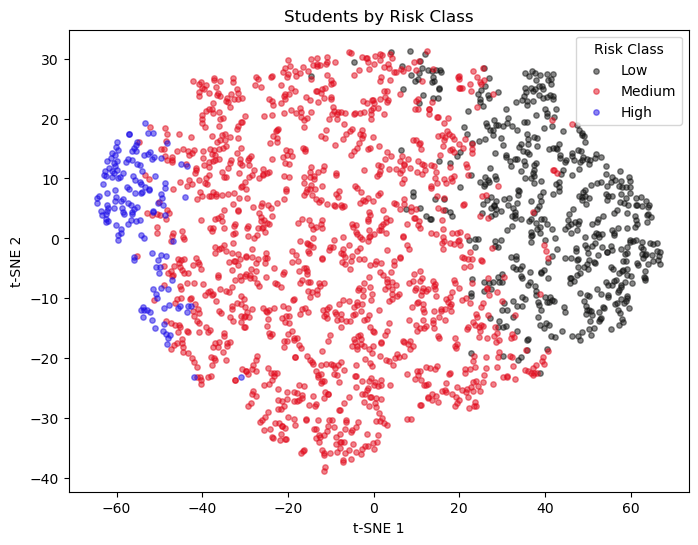

In [15]:
colors_risk = {'Low': "#101110", 'Medium': "#E10B1D", 'High': "#1c0de7"}

plt.figure(figsize=(8, 6))

for label in ['Low', 'Medium', 'High']:
    subset = merged[merged['dominant_risk'] == label]
    plt.scatter(subset['tsne_x'], subset['tsne_y'],
                c=colors_risk[label], label=label, alpha=0.5, s=15)

plt.title('Students by Risk Class')
plt.legend(title='Risk Class')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

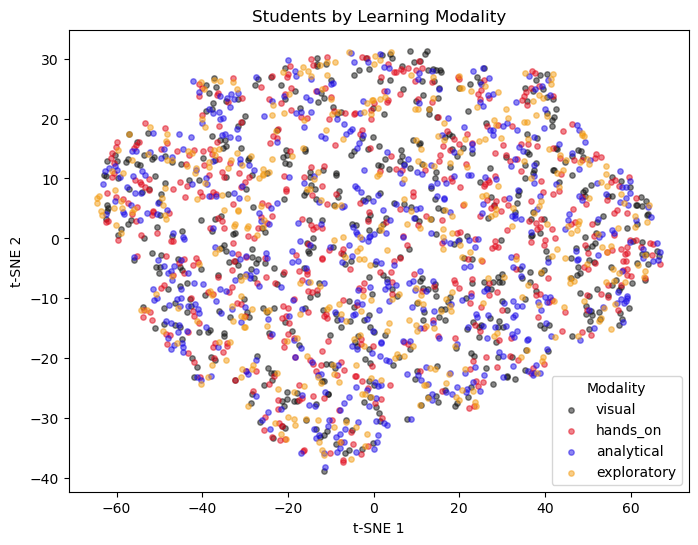

In [16]:
colors_mod = {'visual': '#101110', 'hands_on': '#E10B1D', 'analytical': '#1c0de7', 'exploratory': '#f39c12'}

plt.figure(figsize=(8, 6))

for mod in ['visual', 'hands_on', 'analytical', 'exploratory']:
    subset = merged[merged['true_modality'] == mod]
    plt.scatter(subset['tsne_x'], subset['tsne_y'],
                c=colors_mod[mod], label=mod, alpha=0.5, s=15)

plt.title('Students by Learning Modality')
plt.legend(title='Modality')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

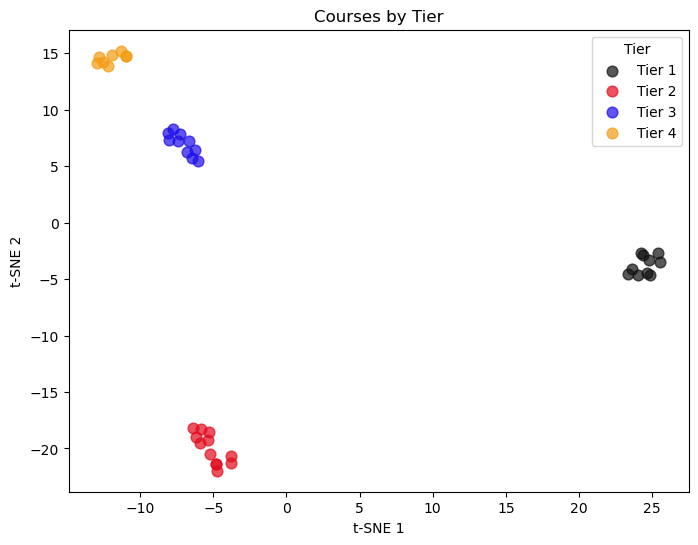

In [17]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

course_features = ['difficulty', 'pass_rate']
X_courses = StandardScaler().fit_transform(courses[course_features].values)

tsne_c = TSNE(n_components=2, random_state=42, perplexity=8)
X_c_2d = tsne_c.fit_transform(X_courses)

colors_tier = {1: '#101110', 2: '#E10B1D', 3: '#1c0de7', 4: '#f39c12'}

plt.figure(figsize=(8, 6))
for tier in [1, 2, 3, 4]:
    mask = courses['tier'] == tier
    plt.scatter(X_c_2d[mask, 0], X_c_2d[mask, 1],
                c=colors_tier[tier], label=f'Tier {tier}', alpha=0.7, s=60)

plt.title('Courses by Tier')
plt.legend(title='Tier')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

In [18]:
print("=== Avg metrics by risk_class ===")
print(merged.groupby('dominant_risk')[['avg_grade', 'avg_confusion', 'skip_rate']].mean().round(3))

print("\n=== Avg grade by modality ===")
print(merged.groupby('true_modality')['avg_grade'].mean().round(3))

=== Avg metrics by risk_class ===
               avg_grade  avg_confusion  skip_rate
dominant_risk                                     
High               1.284          0.517      0.057
Low                2.719          0.152      0.035
Medium             2.058          0.317      0.047

=== Avg grade by modality ===
true_modality
analytical     2.203
exploratory    2.151
hands_on       2.164
visual         2.191
Name: avg_grade, dtype: float64
